In [55]:
pip install efficient-apriori

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\alexa\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [56]:
pip install "numpy>=2.1" "scipy>=1.14"

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\alexa\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [57]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from efficient_apriori import apriori

First dataset

In [58]:
file_name = 'bread basket.csv'

dataset = pd.read_csv(file_name)

print(dataset)

       Transaction           Item         date_time period_day weekday_weekend
0                1          Bread  30-10-2016 09:58    morning         weekend
1                2   Scandinavian  30-10-2016 10:05    morning         weekend
2                2   Scandinavian  30-10-2016 10:05    morning         weekend
3                3  Hot chocolate  30-10-2016 10:07    morning         weekend
4                3            Jam  30-10-2016 10:07    morning         weekend
...            ...            ...               ...        ...             ...
20502         9682         Coffee  09-04-2017 14:32  afternoon         weekend
20503         9682            Tea  09-04-2017 14:32  afternoon         weekend
20504         9683         Coffee  09-04-2017 14:57  afternoon         weekend
20505         9683         Pastry  09-04-2017 14:57  afternoon         weekend
20506         9684      Smoothies  09-04-2017 15:04  afternoon         weekend

[20507 rows x 5 columns]


In [59]:
print(dataset.columns)

Index(['Transaction', 'Item', 'date_time', 'period_day', 'weekday_weekend'], dtype='str')


In [60]:
dataset_transactions = dataset.groupby('Transaction').agg(items=('Item',list))  
print(dataset_transactions['items'])

Transaction
1                                                 [Bread]
2                            [Scandinavian, Scandinavian]
3                           [Hot chocolate, Jam, Cookies]
4                                                [Muffin]
5                                 [Coffee, Pastry, Bread]
                              ...                        
9680                                              [Bread]
9681    [Truffles, Tea, Spanish Brunch, Christmas common]
9682                  [Muffin, Tacos/Fajita, Coffee, Tea]
9683                                     [Coffee, Pastry]
9684                                          [Smoothies]
Name: items, Length: 9465, dtype: object


In [61]:
transactions = dataset_transactions['items'].values.tolist()
itemsets, rules = apriori(transactions, min_support=1e-3,  min_confidence=0.75)
print(f'The number of rules found: {len(rules)}')

The number of rules found: 10


In [62]:
for rule in rules:
    print(rule)

{Extra Salami or Feta} -> {Coffee} (conf: 0.816, supp: 0.003, lift: 1.705, conv: 2.832)
{Keeping It Local} -> {Coffee} (conf: 0.810, supp: 0.005, lift: 1.692, conv: 2.738)
{Cake, Salad} -> {Coffee} (conf: 0.769, supp: 0.001, lift: 1.608, conv: 2.260)
{Cake, Vegan mincepie} -> {Coffee} (conf: 0.833, supp: 0.001, lift: 1.742, conv: 3.130)
{Cookies, Scone} -> {Coffee} (conf: 0.789, supp: 0.002, lift: 1.650, conv: 2.478)
{Extra Salami or Feta, Salad} -> {Coffee} (conf: 0.875, supp: 0.001, lift: 1.829, conv: 4.173)
{Hearty & Seasonal, Sandwich} -> {Coffee} (conf: 0.857, supp: 0.001, lift: 1.792, conv: 3.651)
{Juice, Pastry} -> {Coffee} (conf: 0.773, supp: 0.002, lift: 1.615, conv: 2.295)
{Pastry, Toast} -> {Coffee} (conf: 0.867, supp: 0.001, lift: 1.812, conv: 3.912)
{Salad, Sandwich} -> {Coffee} (conf: 0.833, supp: 0.002, lift: 1.742, conv: 3.130)


Second dataset

In [63]:
file_name = 'Groceries data.csv'

dataset = pd.read_csv(file_name)

print(dataset)

       Member_number        Date        itemDescription  year  month  day  \
0               1808  2015-07-21         tropical fruit  2015      7   21   
1               2552  2015-05-01             whole milk  2015      5    1   
2               2300  2015-09-19              pip fruit  2015      9   19   
3               1187  2015-12-12       other vegetables  2015     12   12   
4               3037  2015-01-02             whole milk  2015      1    2   
...              ...         ...                    ...   ...    ...  ...   
38760           4471  2014-08-10          sliced cheese  2014      8   10   
38761           2022  2014-02-23                  candy  2014      2   23   
38762           1097  2014-04-16               cake bar  2014      4   16   
38763           1510  2014-03-12  fruit/vegetable juice  2014      3   12   
38764           1521  2014-12-26               cat food  2014     12   26   

       day_of_week  
0                1  
1                4  
2           

In [64]:
print(dataset.columns)

Index(['Member_number', 'Date', 'itemDescription', 'year', 'month', 'day',
       'day_of_week'],
      dtype='str')


In [65]:
dataset_transactions = dataset.groupby('Member_number').agg(items=('itemDescription',list))  
print(dataset_transactions['items'])

Member_number
1000    [soda, canned beer, sausage, sausage, whole mi...
1001    [frankfurter, frankfurter, beef, sausage, whol...
1002    [tropical fruit, butter milk, butter, frozen v...
1003    [sausage, root vegetables, rolls/buns, deterge...
1004    [other vegetables, pip fruit, root vegetables,...
                              ...                        
4996    [dessert, salty snack, rolls/buns, misc. bever...
4997    [tropical fruit, white wine, whole milk, curd,...
4998                                   [rolls/buns, curd]
4999    [bottled water, butter milk, tropical fruit, b...
5000    [soda, bottled beer, fruit/vegetable juice, ro...
Name: items, Length: 3898, dtype: object


In [66]:
transactions = dataset_transactions['items'].values.tolist()
itemsets, rules = apriori(transactions, min_support=2e-3,  min_confidence=0.9)
print(f'The number of rules found: {len(rules)}')

The number of rules found: 967


In [67]:
for rule in rules:
    print(rule)

{whisky} -> {whole milk} (conf: 1.000, supp: 0.002, lift: 2.183, conv: 541816316.060)
{beef, finished products} -> {whole milk} (conf: 0.909, supp: 0.003, lift: 1.984, conv: 5.960)
{brandy, yogurt} -> {whole milk} (conf: 0.909, supp: 0.003, lift: 1.984, conv: 5.960)
{butter, pot plants} -> {other vegetables} (conf: 0.917, supp: 0.003, lift: 2.434, conv: 7.481)
{cake bar, coffee} -> {whole milk} (conf: 0.923, supp: 0.003, lift: 2.015, conv: 7.044)
{candles, curd} -> {rolls/buns} (conf: 0.900, supp: 0.002, lift: 2.574, conv: 6.503)
{candy, herbs} -> {whole milk} (conf: 0.909, supp: 0.003, lift: 1.984, conv: 5.960)
{candy, red/blush wine} -> {whole milk} (conf: 0.900, supp: 0.002, lift: 1.964, conv: 5.418)
{canned beer, curd cheese} -> {whole milk} (conf: 0.900, supp: 0.002, lift: 1.964, conv: 5.418)
{canned fish, soft cheese} -> {pip fruit} (conf: 1.000, supp: 0.002, lift: 5.862, conv: 829399692.150)
{canned vegetables, pork} -> {whole milk} (conf: 0.909, supp: 0.003, lift: 1.984, conv: 

In [68]:
rules_rhs = filter(lambda rule: len(rule.lhs) == 2 and len(rule.rhs) == 1, rules)
for rule in sorted(rules_rhs, key=lambda rule: rule.lift)[::-1]:
  print(rule)

{canned fish, soft cheese} -> {pip fruit} (conf: 1.000, supp: 0.002, lift: 5.862, conv: 829399692.150)
{sliced cheese, waffles} -> {yogurt} (conf: 0.933, supp: 0.004, lift: 3.298, conv: 10.756)
{finished products, white bread} -> {other vegetables} (conf: 1.000, supp: 0.002, lift: 2.655, conv: 623396613.648)
{frozen potato products, long life bakery product} -> {rolls/buns} (conf: 0.900, supp: 0.002, lift: 2.574, conv: 6.503)
{candles, curd} -> {rolls/buns} (conf: 0.900, supp: 0.002, lift: 2.574, conv: 6.503)
{photo/film, shopping bags} -> {other vegetables} (conf: 0.917, supp: 0.003, lift: 2.434, conv: 7.481)
{butter, pot plants} -> {other vegetables} (conf: 0.917, supp: 0.003, lift: 2.434, conv: 7.481)
{kitchen towels, sausage} -> {other vegetables} (conf: 0.909, supp: 0.003, lift: 2.414, conv: 6.857)
{cat food, oil} -> {other vegetables} (conf: 0.909, supp: 0.003, lift: 2.414, conv: 6.857)
{frozen vegetables, rice} -> {other vegetables} (conf: 0.900, supp: 0.002, lift: 2.390, conv: 

In [69]:
pip install --upgrade scipy  # fixes numpy 2.x compatibility, i had quite some versionning issues...

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\alexa\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


## FP-Growth Analysis (mlxtend)

FP-Growth avoids the expensive candidate generation
of Apriori by compressing the database into an **FP-tree** and mining it directly.
It is typically **10–100× faster** than Apriori on dense datasets.

We use **mlxtend** which provides a DataFrame-based API and richer rule metrics:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **Support** | P(A ∪ B) | How often the itemset appears |
| **Confidence** | P(B \| A) | Rule correctness given antecedent |
| **Lift** | P(B \| A) / P(B) | Strength vs. random chance (>1 = positive) |
| **Leverage** | P(A ∪ B) − P(A)·P(B) | Co-occurrence surplus over independence |
| **Conviction** | (1−P(B))/(1−conf) | How misleading the rule is when wrong |
| **Zhang's metric** | symmetric corr. | −1 (negative) to +1 (perfect) |

In [70]:
pip install mlxtend -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\alexa\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### Dataset 1 - Bread Basket : FP-Growth

In [71]:
from mlxtend.frequent_patterns import fpgrowth, association_rules
# Note: mlxtend.preprocessing is incompatible with scipy on Python 3.13.
# We build the one-hot transaction matrix with pd.crosstab (pure pandas, no scipy) since I had many version issues :/

# Reload so this section is self-contained
bb_raw = pd.read_csv('bread basket.csv')

# pd.crosstab gives a Transaction × Item count matrix; clip to bool for FP-Growth
bb_ohe = pd.crosstab(bb_raw['Transaction'], bb_raw['Item']).astype(bool)

freq_bb   = fpgrowth(bb_ohe, min_support=0.005, use_colnames=True)
freq_bb['length'] = freq_bb['itemsets'].apply(len)

print(f"Frequent itemsets (min_support=0.5%): {len(freq_bb)}")
freq_bb.sort_values('support', ascending=False).head(10)

Frequent itemsets (min_support=0.5%): 114


,support,itemsets,length
6,0.478394,frozenset({Coffee}),1
0,0.327205,frozenset({Bread}),1
9,0.142631,frozenset({Tea}),1
18,0.103856,frozenset({Cake}),1
37,0.090016,"frozenset({Coffee, Bread})",2
7,0.086107,frozenset({Pastry}),1
21,0.071844,frozenset({Sandwich}),1
8,0.061807,frozenset({Medialuna}),1
2,0.058320,frozenset({Hot chocolate}),1
82,0.054728,"frozenset({Cake, Coffee})",2


In [72]:
rules_bb = association_rules(
    freq_bb, metric='lift', min_threshold=1.0,
    num_itemsets=len(freq_bb)
)

# Zhang's metric - symmetric correlation measure
def zhang(row):
    num = row['support'] - row['antecedent support'] * row['consequent support']
    den = max(
        row['support'] * (1 - row['antecedent support']),
        row['antecedent support'] * (row['consequent support'] - row['support'])
    )
    return num / den if den != 0 else 0.0

rules_bb['leverage'] = (rules_bb['support']
                        - rules_bb['antecedent support']
                        * rules_bb['consequent support'])
rules_bb['zhang'] = rules_bb.apply(zhang, axis=1)

print(f"Total rules (lift >= 1): {len(rules_bb)}")
print("\nTop 10 rules by Lift:")
(rules_bb
 .sort_values('confidence', ascending=False)
 .head(10)
 [['antecedents', 'consequents', 'support', 'confidence', 'lift', 'conviction', 'zhang']]
)



Total rules (lift >= 1): 104

Top 10 rules by Lift:


,antecedents,consequents,support,confidence,lift,conviction,zhang
87,frozenset({Keeping It Local}),frozenset({Coffee}),0.005388,0.809524,1.692169,2.738431,0.411783
93,frozenset({Toast}),frozenset({Coffee}),0.023666,0.704403,1.472431,1.764582,0.332006
101,frozenset({Salad}),frozenset({Coffee}),0.006550,0.626263,1.309094,1.395648,0.238608
9,"frozenset({Cake, Hot chocolate})",frozenset({Coffee}),0.006867,0.601852,1.258067,1.310080,0.207497
103,frozenset({Spanish Brunch}),frozenset({Coffee}),0.010882,0.598837,1.251766,1.300235,0.204851
38,frozenset({Medialuna}),frozenset({Coffee}),0.035182,0.569231,1.189878,1.210871,0.170091
30,frozenset({Pastry}),frozenset({Coffee}),0.047544,0.552147,1.154168,1.164682,0.146161
91,frozenset({Tiffin}),frozenset({Coffee}),0.008452,0.547945,1.145385,1.153856,0.128919
79,frozenset({Alfajores}),frozenset({Coffee}),0.019651,0.540698,1.130235,1.135648,0.119574
53,frozenset({Hearty & Seasonal}),frozenset({Coffee}),0.005705,0.540000,1.128777,1.133926,0.115303


In [73]:
# Top-3 Highest support:
(rules_bb
 .sort_values('support', ascending=False)
 .head(3)
 [['antecedents', 'consequents', 'support', 'confidence', 'lift', 'conviction', 'zhang']]
)

,antecedents,consequents,support,confidence,lift,conviction,zhang
59,frozenset({Coffee}),frozenset({Cake}),0.054728,0.114399,1.101515,1.011905,0.176684
58,frozenset({Cake}),frozenset({Coffee}),0.054728,0.526958,1.101515,1.102664,0.102840
30,frozenset({Pastry}),frozenset({Coffee}),0.047544,0.552147,1.154168,1.164682,0.146161


In [74]:
# Top-3 Highest confidence:
(rules_bb
 .sort_values('confidence', ascending=False)
 .head(3)
 [['antecedents', 'consequents', 'support', 'confidence', 'lift', 'conviction', 'zhang']]
)



,antecedents,consequents,support,confidence,lift,conviction,zhang
87,frozenset({Keeping It Local}),frozenset({Coffee}),0.005388,0.809524,1.692169,2.738431,0.411783
93,frozenset({Toast}),frozenset({Coffee}),0.023666,0.704403,1.472431,1.764582,0.332006
101,frozenset({Salad}),frozenset({Coffee}),0.006550,0.626263,1.309094,1.395648,0.238608


In [95]:
# Top-3 Highest lift:
(rules_bb
 .sort_values('lift', ascending=False)
 .head(10)
 [['antecedents', 'consequents', 'support', 'confidence', 'lift', 'conviction', 'zhang']]
)

,antecedents,consequents,support,confidence,lift,conviction,zhang
69,frozenset({Sandwich}),frozenset({Coke}),0.005177,0.072059,3.706722,1.056705,0.786742
68,frozenset({Coke}),frozenset({Sandwich}),0.005177,0.266304,3.706722,1.265043,0.744697
44,frozenset({Juice}),frozenset({Cookies}),0.006128,0.158904,2.920442,1.124234,0.683962
45,frozenset({Cookies}),frozenset({Juice}),0.006128,0.112621,2.920442,1.083457,0.695425
10,"frozenset({Coffee, Hot chocolate})",frozenset({Cake}),0.006867,0.232143,2.235231,1.167071,0.569465
11,frozenset({Cake}),"frozenset({Coffee, Hot chocolate})",0.006867,0.066124,2.235231,1.039129,0.616663
56,frozenset({Sandwich}),frozenset({Soup}),0.005494,0.076471,2.220227,1.045508,0.592137
57,frozenset({Soup}),frozenset({Sandwich}),0.005494,0.159509,2.220227,1.104303,0.569200
13,frozenset({Hot chocolate}),"frozenset({Cake, Coffee})",0.006867,0.117754,2.151618,1.071438,0.568382
8,"frozenset({Cake, Coffee})",frozenset({Hot chocolate}),0.006867,0.125483,2.151618,1.076800,0.566222


In [97]:
# Top-3 Highest leverage:
(rules_bb
 .sort_values('leverage', ascending=False)
 .head(3)
 [['antecedents', 'consequents', 'support', 'confidence', 'lift', 'conviction', 'zhang']]
)



,antecedents,consequents,support,confidence,lift,conviction,zhang
61,frozenset({Cake}),frozenset({Tea}),0.023772,0.228891,1.604781,1.111865,0.420538
60,frozenset({Tea}),frozenset({Cake}),0.023772,0.166667,1.604781,1.075372,0.439556
92,frozenset({Coffee}),frozenset({Toast}),0.023666,0.049470,1.472431,1.016699,0.615122


In [ ]:
# Top-3 Highest conviction:
(rules_bb
 .sort_values('conviction', ascending=False)
 .head(3)
 [['antecedents', 'consequents', 'support', 'confidence', 'lift', 'conviction', 'zhang']]
)

,antecedents,consequents,support,confidence,lift,leverage,conviction,zhang
87,frozenset({Keeping It Local}),frozenset({Coffee}),0.005388,0.809524,1.692169,0.002204,2.738431,0.411783
93,frozenset({Toast}),frozenset({Coffee}),0.023666,0.704403,1.472431,0.007593,1.764582,0.332006
101,frozenset({Salad}),frozenset({Coffee}),0.006550,0.626263,1.309094,0.001547,1.395648,0.238608


In [ ]:
# Top-10 Highest zhang:
(rules_bb
 .sort_values('zhang', ascending=False)
 .head(10)
 [['antecedents', 'consequents', 'support', 'confidence', 'lift', 'conviction', 'zhang']]
)

,antecedents,consequents,support,confidence,lift,leverage,conviction,zhang
69,frozenset({Sandwich}),frozenset({Coke}),0.005177,0.072059,3.706722,0.003780,1.056705,0.786742
86,frozenset({Coffee}),frozenset({Keeping It Local}),0.005388,0.011263,1.692169,0.002204,1.004660,0.784199
68,frozenset({Coke}),frozenset({Sandwich}),0.005177,0.266304,3.706722,0.003780,1.265043,0.744697
45,frozenset({Cookies}),frozenset({Juice}),0.006128,0.112621,2.920442,0.004030,1.083457,0.695425
44,frozenset({Juice}),frozenset({Cookies}),0.006128,0.158904,2.920442,0.004030,1.124234,0.683962
11,frozenset({Cake}),"frozenset({Coffee, Hot chocolate})",0.006867,0.066124,2.235231,0.003795,1.039129,0.616663
92,frozenset({Coffee}),frozenset({Toast}),0.023666,0.049470,1.472431,0.007593,1.016699,0.615122
56,frozenset({Sandwich}),frozenset({Soup}),0.005494,0.076471,2.220227,0.003019,1.045508,0.592137
10,"frozenset({Coffee, Hot chocolate})",frozenset({Cake}),0.006867,0.232143,2.235231,0.003795,1.167071,0.569465
57,frozenset({Soup}),frozenset({Sandwich}),0.005494,0.159509,2.220227,0.003019,1.104303,0.569200


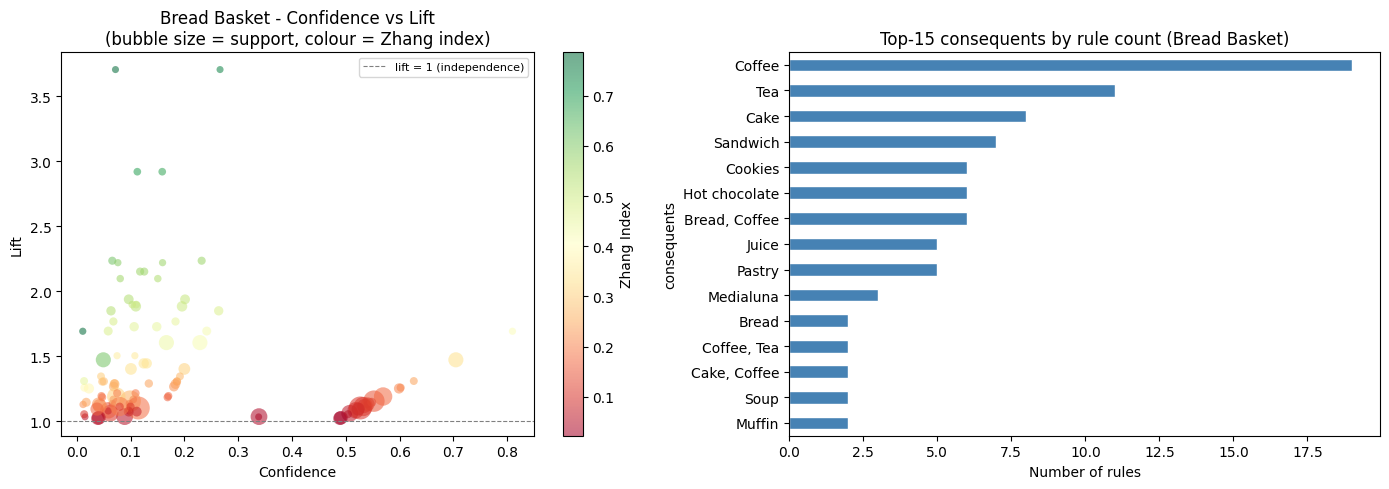

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confidence vs Lift scatter (size = support, colour = leverage)
sc = axes[0].scatter(
    rules_bb['confidence'], rules_bb['lift'],
    s=rules_bb['support'] * 5000, alpha=0.55,
    c=rules_bb['zhang'], cmap='RdYlGn', edgecolors='none'
)
plt.colorbar(sc, ax=axes[0], label='Zhang Index')
axes[0].axhline(1, color='grey', ls='--', lw=0.8, label='lift = 1 (independence)')
axes[0].set(xlabel='Confidence', ylabel='Lift',
            title='Bread Basket - Confidence vs Lift\n(bubble size = support, colour = Zhang index)')
axes[0].legend(fontsize=8)

# Top-15 consequents by rule count
top_cons = (
    rules_bb['consequents']
    .apply(lambda x: ', '.join(sorted(x)))
    .value_counts()
    .head(15)
)
top_cons.sort_values().plot.barh(ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set(title='Top-15 consequents by rule count (Bread Basket)',
            xlabel='Number of rules')

plt.tight_layout()
plt.show()

### Dataset 2 - Groceries : FP-Growth

> **Grouping note:** The existing cells group by `Member_number`, treating each
> member's full purchase history as one "basket". Below we additionally group by
> **(Member_number, Date)** - treating each shopping trip as a distinct basket -
> which gives more realistic market-basket statistics for recommendation purposes.

In [ ]:
gr_raw = pd.read_csv('Groceries data.csv')

# Group by Member_number only - treats full purchase history as one basket.
# (Member+Date grouping yields baskets of 1–2 items, too sparse for rules.)
gr_ohe = pd.crosstab(gr_raw['Member_number'], gr_raw['itemDescription']).astype(bool)

freq_gr = fpgrowth(gr_ohe, min_support=0.03, use_colnames=True)
freq_gr['length'] = freq_gr['itemsets'].apply(len)

print(f"Frequent itemsets (min_support=3%, per-member grouping): {len(freq_gr)}")
freq_gr.sort_values('support', ascending=False).head(10)

Frequent itemsets (min_support=3%, per-member grouping): 415


,support,itemsets,length
0,0.458184,frozenset({whole milk}),1
17,0.376603,frozenset({other vegetables}),1
11,0.349666,frozenset({rolls/buns}),1
1,0.313494,frozenset({soda}),1
2,0.282966,frozenset({yogurt}),1
18,0.233710,frozenset({tropical fruit}),1
24,0.230631,frozenset({root vegetables}),1
33,0.213699,frozenset({bottled water}),1
3,0.206003,frozenset({sausage}),1
189,0.191380,"frozenset({other vegetables, whole milk})",2


In [ ]:
rules_gr = association_rules(
    freq_gr, metric='lift', min_threshold=1.0,
    num_itemsets=len(freq_gr)
)
rules_gr['leverage'] = (rules_gr['support']
                        - rules_gr['antecedent support']
                        * rules_gr['consequent support'])
rules_gr['zhang'] = rules_gr.apply(zhang, axis=1)

print(f"Total rules: {len(rules_gr)}")
print("\nTop 10 by Lift (antecedent support > 5%):")
(rules_gr
 .query('`antecedent support` > 0.05')
 .sort_values('lift', ascending=False)
 .head(10)
 [['antecedents', 'consequents', 'support', 'confidence', 'lift', 'conviction', 'zhang']]
)

Total rules: 1044

Top 10 by Lift (antecedent support > 5%):


,antecedents,consequents,support,confidence,lift,conviction,zhang
89,"frozenset({other vegetables, whole milk})","frozenset({rolls/buns, yogurt})",0.034377,0.179625,1.613311,1.083237,0.470130
88,"frozenset({rolls/buns, yogurt})","frozenset({other vegetables, whole milk})",0.034377,0.308756,1.613311,1.169803,0.427786
87,"frozenset({rolls/buns, whole milk})","frozenset({other vegetables, yogurt})",0.034377,0.192529,1.600164,1.089428,0.456590
90,"frozenset({other vegetables, yogurt})","frozenset({rolls/buns, whole milk})",0.034377,0.285714,1.600164,1.150026,0.426363
91,"frozenset({whole milk, yogurt})","frozenset({rolls/buns, other vegetables})",0.034377,0.228279,1.555652,1.105657,0.420507
86,"frozenset({rolls/buns, other vegetables})","frozenset({whole milk, yogurt})",0.034377,0.234266,1.555652,1.109275,0.418610
137,"frozenset({rolls/buns, yogurt})",frozenset({sausage}),0.035659,0.320276,1.554717,1.168118,0.401499
140,frozenset({sausage}),"frozenset({rolls/buns, yogurt})",0.035659,0.173101,1.554717,1.074691,0.449367
141,frozenset({yogurt}),"frozenset({rolls/buns, sausage})",0.035659,0.126020,1.530298,1.049967,0.483286
136,"frozenset({rolls/buns, sausage})",frozenset({yogurt}),0.035659,0.433022,1.530298,1.264660,0.377630


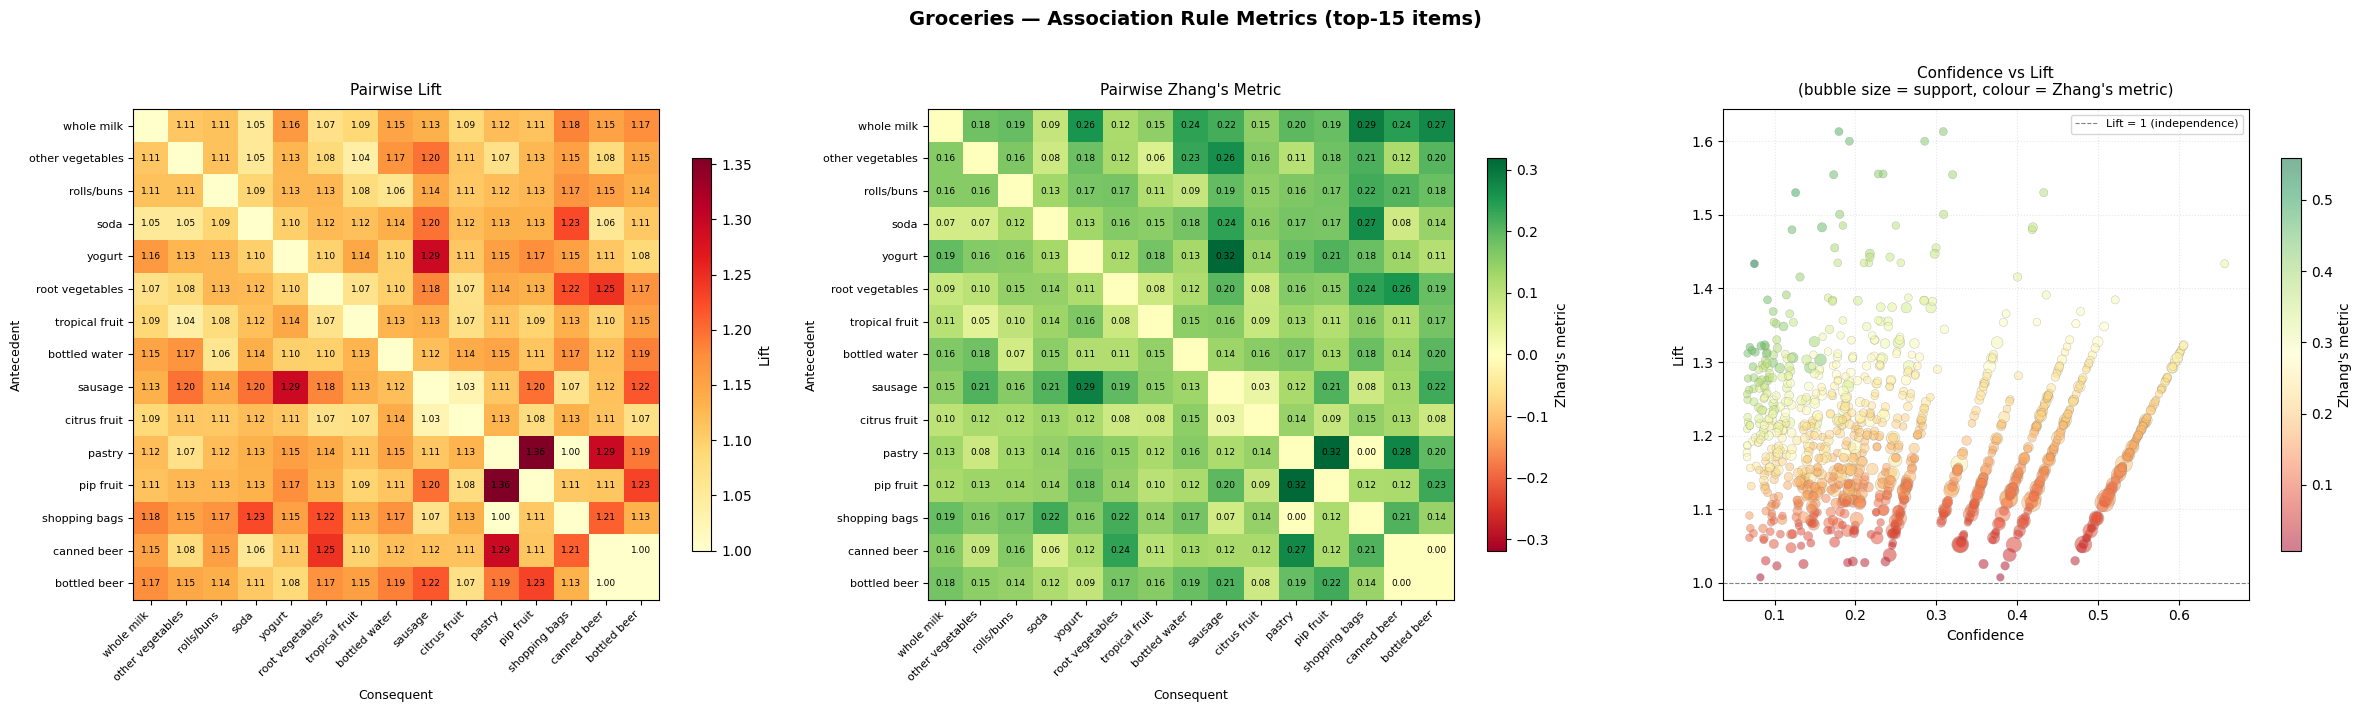

In [98]:
N_ITEMS = 15

def build_matrix(rules, items, metric, fill=1.0):
    mat = pd.DataFrame(fill, index=items, columns=items)
    for _, row in rules.iterrows():
        ant, con = list(row['antecedents']), list(row['consequents'])
        if len(ant) == 1 and len(con) == 1:
            a, c = ant[0], con[0]
            if a in items and c in items:
                mat.loc[a, c] = row[metric]
    return mat

def annotate_heatmap(ax, values, fontsize=6.5):
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            if i != j:  # skip diagonal — it's always the fill value, not meaningful
                ax.text(j, i, f'{values[i, j]:.2f}',
                        ha='center', va='center', fontsize=fontsize, color='black')

top_items = gr_raw['itemDescription'].value_counts().head(N_ITEMS).index.tolist()
lift_mat  = build_matrix(rules_gr, top_items, 'lift')
zhang_mat = build_matrix(rules_gr, top_items, 'zhang', fill=0.0)

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle('Groceries — Association Rule Metrics (top-15 items)', fontsize=14, fontweight='bold', y=1.01)

tick_kwargs = dict(rotation=45, ha='right', fontsize=8)

def setup_heatmap_axes(ax, items):
    ax.set_xticks(range(len(items)))
    ax.set_yticks(range(len(items)))
    ax.set_xticklabels(items, **tick_kwargs)
    ax.set_yticklabels(items, fontsize=8)
    ax.set_xlabel('Consequent', fontsize=9)
    ax.set_ylabel('Antecedent', fontsize=9)

# ── Lift heatmap ───────────────────────────────────────────────────────────────
im0 = axes[0].imshow(lift_mat.values, cmap='YlOrRd', aspect='auto', vmin=1.0)
plt.colorbar(im0, ax=axes[0], shrink=0.8, label='Lift')
setup_heatmap_axes(axes[0], top_items)
annotate_heatmap(axes[0], lift_mat.values)
axes[0].set_title('Pairwise Lift', fontsize=11, pad=10)

# ── Zhang heatmap ──────────────────────────────────────────────────────────────
lim = max(abs(zhang_mat.values.min()), abs(zhang_mat.values.max()))  # symmetric colorbar
im1 = axes[1].imshow(zhang_mat.values, cmap='RdYlGn', aspect='auto', vmin=-lim, vmax=lim)
plt.colorbar(im1, ax=axes[1], shrink=0.8, label="Zhang's metric")
setup_heatmap_axes(axes[1], top_items)
annotate_heatmap(axes[1], zhang_mat.values)
axes[1].set_title("Pairwise Zhang's Metric", fontsize=11, pad=10)

# ── Confidence vs Lift scatter ─────────────────────────────────────────────────
ax2 = axes[2]
if len(rules_gr) > 0:
    sc = ax2.scatter(
        rules_gr['confidence'], rules_gr['lift'],
        s=rules_gr['support'] * 1000, alpha=0.5,
        c=rules_gr['zhang'], cmap='RdYlGn',
        edgecolors='grey', linewidths=0.3
    )
    plt.colorbar(sc, ax=ax2, shrink=0.8, label='Zhang\'s metric')
    ax2.axhline(1, color='grey', ls='--', lw=0.8, label='Lift = 1 (independence)')
    ax2.legend(fontsize=8)
    ax2.set_xlabel('Confidence', fontsize=10)
    ax2.set_ylabel('Lift', fontsize=10)
    ax2.set_title('Confidence vs Lift\n(bubble size = support, colour = Zhang\'s metric)', fontsize=11, pad=10)
    ax2.grid(True, alpha=0.3, linestyle=':')
else:
    ax2.text(0.5, 0.5, 'No rules to display', ha='center', va='center',
             transform=ax2.transAxes, fontsize=12, color='grey')
    ax2.set_title('Confidence vs Lift', fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
# Top rules by each metric
metrics_to_rank = ['lift', 'confidence', 'support', 'conviction', 'zhang']

for m in metrics_to_rank:
    top = (rules_gr
           .sort_values(m, ascending=False)
           .head(3)
           [['antecedents', 'consequents', 'support', 'confidence', 'lift', 'conviction', 'zhang']])
    print(f"--- Top 3 by {m.upper()} ---")
    print(top.to_string(index=False))
    print()

--- Top 3 by LIFT ---
                              antecedents                               consequents  support  confidence     lift  conviction    zhang
frozenset({other vegetables, whole milk})           frozenset({rolls/buns, yogurt}) 0.034377    0.179625 1.613311    1.083237 0.470130
          frozenset({rolls/buns, yogurt}) frozenset({other vegetables, whole milk}) 0.034377    0.308756 1.613311    1.169803 0.427786
      frozenset({rolls/buns, whole milk})     frozenset({other vegetables, yogurt}) 0.034377    0.192529 1.600164    1.089428 0.456590

--- Top 3 by CONFIDENCE ---
                                      antecedents             consequents  support  confidence     lift  conviction    zhang
frozenset({rolls/buns, other vegetables, yogurt}) frozenset({whole milk}) 0.034377    0.656863 1.433623    1.579008 0.319170
               frozenset({bottled water, yogurt}) frozenset({whole milk}) 0.040277    0.606178 1.323001    1.375788 0.261519
            frozenset({bottled bee

# comment (unsure):

- If high lift between A => B, to test if the relation is profitable, put a bundle for both items, and test if the confidence between A => B gets higher. In fact, since Lift is high, such measure should be quite likely to work and higher confidence and support (both) or only buy A, especially if zhang is positive but not that high. If zhang or confidence is close to 1, it doesn't matter much to do marketing since there is already a big association between A and B.
